# EmotioNet on DEAP: EEG-based emotion recognition with a 3-D CNN

This notebook re-implements **EmotioNet** (Wang, Huang, McCane & Neo, *IJCNN 2018*) in PyTorch and evaluates it on the **DEAP** dataset (Koelstra et al., *IEEE Trans. Affective Computing*, 2012).

** The dataset. ** In the DEAP dataset, 32 participants rated their emotional response to 40 one-minute music-video excerpts while their EEG was recorded.

**The task.** We will focus on valence and arousal ratings, transforming the original 1-9 rating to a binary low/high rating split at 5.

**The experiments.** We train and score the model using a within subject protocol.Leave-K-Trials-Out cross-validation is used to train the model for each subject, best validation balanced accuracy is reported.

**Contents**

1. Setup and configuration
2. The DEAP dataset
3. Preprocessing: from channels to a scalp grid
4. The EmotioNet model
5. Data pipeline: windows, trials and loaders
6. Training procedure
7. Within-subject experiment

---
## 1. Setup and configuration

In [ ]:
import copy
import glob
import os
import pickle
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from torch.nn import CrossEntropyLoss
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset

# ── Paths ───────────────────────────────────────────────────────────────────
DEAP_DIR    = "deap-dataset/data_preprocessed_python"   # s01.dat ... s32.dat
RESULTS_DIR = "results"                                 # models + training histories
PLOTS_DIR   = "plots"
CACHE_DIR   = "preprocessing"                                         # local cache of the grid-shaped data

# ── Experiment settings ─────────────────────────────────────────────────────
TARGETS     = ["valence", "arousal"]   # which affective dimensions to classify
SUBJECTS    = None                     # None = all 32 subjects
SEED        = 26

# Windowing: each 60 s trial is cut into overlapping 4 s windows
WINDOW_SIZE = 512                      # samples (4 s at 128 Hz)
STRIDE      = 128                      # samples (1 s) -> 75 % overlap between consecutive windows

# Model / optimisation
DROPOUT     = 0.5
LR          = 1e-3
N_EPOCHS    = 30                       # upper bound; early stopping usually ends training sooner
PATIENCE    = 5                        # epochs without validation-loss improvement before stopping

# Protocol-specific
WITHIN_K          = 5                  # trials held out per within-subject fold (40 trials -> 8 folds)
WITHIN_FOLD_SEED  = 26                 # seed for the trial shuffle that defines the folds
WITHIN_BATCH_SIZE = 32
BETWEEN_BATCH_SIZE = 32

NUM_WORKERS = 4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

print(f"Device: {DEVICE}" + ("" if DEVICE == "cuda" else "  (no GPU found: training will be very slow)"))

Device: cuda


---
## 2. The DEAP dataset

**DEAP** contains recordings from 32 participants, each watching 40 one-minute music-video excerpts. After every video the participant rated their **valence, arousal, dominance and liking** on a 1–9 scale. We use the *preprocessed Python* release, in which each `sNN.dat` file holds one subject:

- `data`: shape `(40 trials, 40 channels, 8064 samples)`. The first 32 channels are EEG, the remaining 8 are peripheral signals, which we discard. The signals are downsampled to **128 Hz**, band-pass filtered (4–45 Hz) and cleaned of eye artefacts. Each trial is 63 s long: a 3 s pre-trial baseline followed by 60 s of stimulus.
- `labels`: shape `(40 trials, 4 ratings)`.

The cell below loads all subjects into a single array and **binarises each rating at 5** (`> 5` = "high"). We keep all four targets, but only valence and arousal are used in the experiments.

In [3]:
DEAP_N_SUBJECTS = 32
DEAP_LABELS = {"valence": 0, "arousal": 1, "dominance": 2, "liking": 3}   # column order in the label array
DEAP_SFREQ = 128                                                          # Hz
DEAP_N_EEG_CHANNELS = 32
DEAP_CHANNEL_ORDER = [
    'Fp1', 'AF3', 'F7', 'F3', 'FC1', 'FC5', 'T7', 'C3',
    'CP1', 'CP5', 'P7', 'P3', 'Pz', 'PO3', 'O1', 'Oz',
    'O2', 'PO4', 'P4', 'P8', 'CP6', 'CP2', 'C4', 'T8',
    'FC6', 'FC2', 'F4', 'F8', 'AF4', 'Fp2', 'Fz', 'Cz'
]
DEAP_LABEL_THRESHOLD = 5.0


def load_subject(filepath):
    """Load one DEAP .dat file -> (EEG data, binarised labels for all 4 targets)."""
    with open(filepath, "rb") as f:
        subject = pickle.load(f, encoding="latin1")
    data = subject["data"][:, :DEAP_N_EEG_CHANNELS]          # (40, 32, 8064): keep EEG channels only
    labels = subject["labels"] > DEAP_LABEL_THRESHOLD        # (40, 4) booleans: valence, arousal, dominance, liking
    return data, labels


def load_all_subjects(data_dir, n_subjects=DEAP_N_SUBJECTS):
    """Load every subject and stack them along a new leading axis."""
    all_data, all_labels = [], []
    for i in range(1, n_subjects + 1):
        fname = os.path.join(data_dir, f"s{i:02d}.dat")
        if not os.path.exists(fname):
            print(f"Skipping missing file: {fname}")
            continue
        data, labels = load_subject(fname)
        all_data.append(data)
        all_labels.append(labels)
    return np.array(all_data), np.array(all_labels)


deap_data, deap_labels_all = load_all_subjects(DEAP_DIR)
print(f"EEG data : {deap_data.shape}   (n_subjects, n_trials, n_channels, n_samples)")
print(f"Labels   : {deap_labels_all.shape}   (n_subjects, n_trials, n_targets)")

EEG data : (32, 40, 32, 8064)   (n_subjects, n_trials, n_channels, n_samples)
Labels   : (32, 40, 4)   (n_subjects, n_trials, n_targets)


With all 32 subjects present you should see `(32, 40, 32, 8064)` for the data and `(32, 40, 4)` for the labels.

### Class balance

Because the ratings are split at a fixed threshold, the two classes are not necessarily equally frequent. This matters for both training (we will weight the loss) and evaluation (we will report *balanced* accuracy).

In [4]:
balance = pd.DataFrame({
    target: {"% high": 100 * deap_labels_all[:, :, idx].mean(), "% low": 100 * (1 - deap_labels_all[:, :, idx].mean())}
    for target, idx in DEAP_LABELS.items()
}).T.round(1)
balance

,% high,% low
valence,21.0,79.0
arousal,23.3,76.7
dominance,60.9,39.1
liking,66.5,33.5


The classes are clearly imbalanced for at least some targets, so a classifier that always predicts the majority class would score well on plain accuracy while learning nothing. We therefore use **class-weighted cross-entropy** during training and **balanced accuracy** (the mean of per-class recall, chance = 0.5) for evaluation.

---
## 3. Preprocessing: from channels to a scalp grid

Two preprocessing steps prepare the raw signals for the CNN.

**1. Remove the baseline.** The first 3 s of each trial (384 samples) are a pre-stimulus baseline recorded before the video starts. We drop them, leaving 60 s = **7680 samples** per trial.

**2. Arrange channels on a 2-D scalp grid.** EmotioNet's central idea is to reshape the `channels × samples` matrix into a `7 × 9 × samples` volume in which each electrode occupies a cell of a grid mimicking its position on the scalp. Neighbouring electrodes become neighbouring cells, so 2-D spatial kernels can pick up local spatial patterns. Grid cells with no electrode are filled with zeros. The layout below follows the one described in the EmotioNet paper (front of the head at the top).

Electrodes placed on the grid: 31 of 32; not placed: ['Oz']


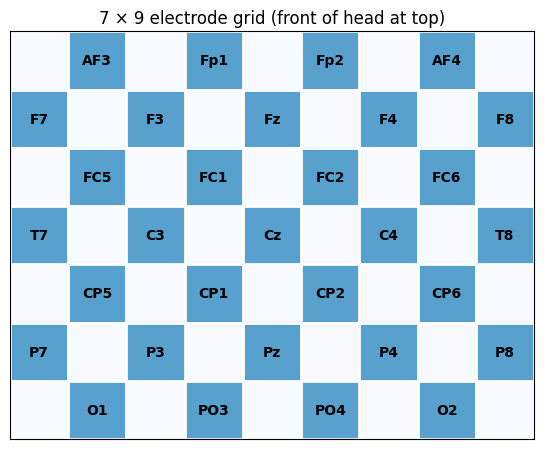

In [5]:
# Row/column layout of the 7x9 grid; None = empty cell (filled with zeros).
TOPO_LAYOUT = [
    [None,  "AF3", None,  "Fp1", None,  "Fp2", None,  "AF4", None],
    ["F7",  None,  "F3",  None,  "Fz",  None,  "F4",  None,  "F8"],
    [None,  "FC5", None,  "FC1", None,  "FC2", None,  "FC6", None],
    ["T7",  None,  "C3",  None,  "Cz",  None,  "C4",  None,  "T8"],
    [None,  "CP5", None,  "CP1", None,  "CP2", None,  "CP6", None],
    ["P7",  None,  "P3",  None,  "Pz",  None,  "P4",  None,  "P8"],
    [None,  "O1",  None,  "PO3", None,  "PO4", None,  "O2",  None],
]

_channel_index = {ch: i for i, ch in enumerate(DEAP_CHANNEL_ORDER)}
GRID_IDX  = np.array([[_channel_index[c] if c else 0 for c in row] for row in TOPO_LAYOUT])   # (7, 9) channel index per cell
GRID_MASK = np.array([[c is not None for c in row] for row in TOPO_LAYOUT])                   # (7, 9) True where an electrode sits

placed = {c for row in TOPO_LAYOUT for c in row if c}
print(f"Electrodes placed on the grid: {len(placed)} of {DEAP_N_EEG_CHANNELS}; not placed: {sorted(set(DEAP_CHANNEL_ORDER) - placed)}")

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.imshow(GRID_MASK, cmap="Blues", vmin=0, vmax=1.8)
for r, row in enumerate(TOPO_LAYOUT):
    for c, name in enumerate(row):
        if name:
            ax.text(c, r, name, ha="center", va="center", fontsize=10, fontweight="bold")
ax.set_xticks(np.arange(-.5, 9, 1), minor=True); ax.set_yticks(np.arange(-.5, 7, 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2); ax.tick_params(which="both", length=0)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("7 × 9 electrode grid (front of head at top)")
plt.tight_layout(); plt.show()

We use `GRID_IDX` to pick for every grid cell the channel that belongs there, and `GRID_MASK` to zero the empty cells.

In [6]:
BASELINE_SAMPLES = 3 * DEAP_SFREQ    # 3 s pre-trial baseline


def cnn_input(data):
    """
    data : (n_subjects, n_trials, n_channels, n_samples)
    returns (n_subjects, n_trials, 7, 9, n_samples) as float32, with each electrode on its grid cell.
    """
    n_subjects, n_trials, _, n_samples = data.shape
    out = np.zeros((n_subjects, n_trials, *GRID_IDX.shape, n_samples), dtype=np.float32)
    for s in range(n_subjects):
        out[s] = data[s][:, GRID_IDX, :] * GRID_MASK[..., None]     # (trials, 7, 9, samples)
    return out


os.makedirs(CACHE_DIR, exist_ok=True)
cache_path = os.path.join(CACHE_DIR, "deap_topo_grid_float32.npy")

if os.path.exists(cache_path):
    inp_data = np.load(cache_path)
else:
    inp_data = cnn_input(deap_data[..., BASELINE_SAMPLES:])        # drop the 3 s baseline, then build the grid
    np.save(cache_path, inp_data)

print(f"CNN input: {inp_data.shape}   (n_subjects, n_trials, grid_h, grid_w, n_samples)")

CNN input: (32, 40, 7, 9, 7680)   (n_subjects, n_trials, grid_h, grid_w, n_samples)


A quick sanity check that the grid really contains what we think it does: the `Fp1` cell must hold the `Fp1` signal (baseline removed), and empty cells must be exactly zero.

In [7]:
fp1_row, fp1_col = [(r, c) for r, row in enumerate(TOPO_LAYOUT) for c, n in enumerate(row) if n == "Fp1"][0]
expected = deap_data[0, 0, DEAP_CHANNEL_ORDER.index("Fp1"), BASELINE_SAMPLES:].astype(np.float32)

assert np.array_equal(inp_data[0, 0, fp1_row, fp1_col], expected), "Fp1 signal not where expected"
assert not inp_data[0, 0][~GRID_MASK].any(), "empty grid cells should be zero"
print("Grid sanity checks passed. Expected shape (32, 40, 7, 9, 7680) for the full dataset.")

Grid sanity checks passed. Expected shape (32, 40, 7, 9, 7680) for the full dataset.


---
## 4. The EmotioNet model

EmotioNet is a convolutional neural network. The first two layers are **3-D convolutions** that mix neighbouring electrodes and neighbouring time samples. A **spatial-fusion** layer then collapses the whole grid into a single point, leaving a purely temporal signal that is processed by two 1-D temporal convolutions. Finally, a **dense-prediction** head scores every remaining time step and *averages those scores over time* to produce the class logits.

Layers 1–5 are each followed by batch normalisation and a ReLU. The table shows the tensor shape after each stage for our 512-sample window (batch and singleton dimensions omitted):

| Stage | Operation | Output (channels × H × W × T) |
|---|---|---|
| Input | 7 × 9 electrode grid, 4 s at 128 Hz | 1 × 7 × 9 × 512 |
| Layer 1 | Conv3d, 20 kernels of 2×2×10, stride 1 | 20 × 6 × 8 × 503 |
| Layer 2 | Conv3d, 20 kernels of 2×2×10, stride (2, 2, 1), **dropout** | 20 × 3 × 4 × 494 |
| Layer 3 | Conv3d *spatial fusion*, 30 kernels spanning the full 3×4 grid | 30 × 1 × 1 × 494 |
| Layer 4 | Conv2d (temporal), 40 kernels of 1×10, **dropout** | 40 × 485 |
| Layer 5 | Conv2d (temporal), 50 kernels of 1×10, **dropout** | 50 × 476 |
| Pooling | Max-pool 1×2 over time | 50 × 238 |
| Layer 6 | 1×1 conv → per-time-step class scores, **mean over time** | 2 logits |

Each of the 238 time steps entering the dense-prediction head sees a receptive field of 38 input samples (about 0.3 s). Averaging their scores gives a prediction for the entire 4 s window, while keeping the parameter count small (roughly 57 k).

The model returns raw **logits**; the softmax is folded into `CrossEntropyLoss`.

In [8]:
class EmotioNet(nn.Module):
    """3-D CNN for EEG-based emotion recognition (Wang et al., IJCNN 2018).

    Args:
        grid_h, grid_w: size of the 2-D electrode grid (7 x 9).
        time_samples:   samples per input window (512 = 4 s at 128 Hz).
        num_classes:    2 for binary high/low valence or arousal.
        dropout_p:      dropout probability in layers 2, 4 and 5.
        pool_kernel:    temporal max-pooling factor (paper: 2).
        use_dense_prediction: if True (paper), score every time step and average; otherwise
            flatten the pooled features into a linear classifier.
    """

    def __init__(self, grid_h=7, grid_w=9, time_samples=512, num_classes=2,
                 dropout_p=0.5, pool_kernel=2, use_dense_prediction=True):
        super().__init__()
        self.use_dense_prediction = use_dense_prediction

        # Layer 1: spatio-temporal 3-D conv (H x W x T kernel), stride 1
        self.conv1 = nn.Conv3d(1, 20, kernel_size=(2, 2, 10), stride=(1, 1, 1))
        self.bn1 = nn.BatchNorm3d(20)

        # Layer 2: 3-D conv with spatial stride 2 -> wider receptive field
        self.conv2 = nn.Conv3d(20, 20, kernel_size=(2, 2, 10), stride=(2, 2, 1))
        self.bn2 = nn.BatchNorm3d(20)
        self.drop2 = nn.Dropout(dropout_p)

        # Layer 3: spatial fusion. The kernel covers the entire remaining spatial extent, so the
        # output has 1x1 spatial size (a purely temporal feature map).
        h1, w1, t1 = self._after_conv3d(grid_h, grid_w, time_samples, (2, 2, 10), (1, 1, 1))
        h2, w2, t2 = self._after_conv3d(h1, w1, t1, (2, 2, 10), (2, 2, 1))
        self.conv3 = nn.Conv3d(20, 30, kernel_size=(h2, w2, 1))
        self.bn3 = nn.BatchNorm3d(30)

        # Layers 4-5: temporal convolutions (Conv2d with a 1 x 10 kernel over a 1 x T map)
        self.conv4 = nn.Conv2d(30, 40, kernel_size=(1, 10))
        self.bn4 = nn.BatchNorm2d(40)
        self.drop4 = nn.Dropout(dropout_p)
        self.conv5 = nn.Conv2d(40, 50, kernel_size=(1, 10))
        self.bn5 = nn.BatchNorm2d(50)
        self.drop5 = nn.Dropout(dropout_p)

        self.pool = nn.MaxPool2d(kernel_size=(1, pool_kernel), stride=(1, pool_kernel))
        t_final = (t2 - 9 - 9) // pool_kernel
        if t_final < 1:
            raise ValueError(f"time_samples={time_samples} is too small for this architecture "
                             f"(temporal length collapses to {t_final}).")

        # Layer 6: output head
        if use_dense_prediction:
            self.dense_pred = nn.Conv2d(50, num_classes, kernel_size=1)
        else:
            self.classifier = nn.Linear(50 * t_final, num_classes)

    @staticmethod
    def _after_conv3d(h, w, t, kernel, stride):
        """Output (H, W, T) of an unpadded 3-D convolution."""
        return tuple((n - k) // s + 1 for n, k, s in zip((h, w, t), kernel, stride))

    def forward(self, x):
        """x: (N, 1, grid_h, grid_w, time_samples) -> logits of shape (N, num_classes)."""
        if x.dim() != 5:
            raise ValueError(f"Expected (N, 1, grid_h, grid_w, time_samples), got {tuple(x.shape)}.")

        x = F.relu(self.bn1(self.conv1(x)))
        x = self.drop2(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))          # (N, 30, 1, 1, T)
        x = x.flatten(2, 3)                          # (N, 30, 1, T): switch from 3-D to 2-D convolutions

        x = self.drop4(F.relu(self.bn4(self.conv4(x))))
        x = self.drop5(F.relu(self.bn5(self.conv5(x))))
        x = self.pool(x)                             # (N, 50, 1, T')

        if self.use_dense_prediction:
            return self.dense_pred(x).squeeze(2).mean(dim=-1)   # per-step scores averaged over time
        return self.classifier(torch.flatten(x, start_dim=1))


def build_model():
    return EmotioNet(grid_h=7, grid_w=9, time_samples=WINDOW_SIZE, num_classes=2, dropout_p=DROPOUT).to(DEVICE)

---
## 5. Data pipeline: windows, trials and loaders

The network takes **4 s windows** (512 samples), not whole 60 s trials. Cutting each trial into windows with a 1 s stride gives 57 overlapping windows per trial, which multiplies the amount of training data and keeps the input small. Every window inherits the label of the trial it came from, since ratings are given per trial, not per second.

`EEGWindowDataset` enumerates every `(subject, trial, start_sample)` combination lazily and returns a window together with its label and a **trial id**. The trial id lets us later regroup window-level outputs into one prediction *per trial*.

Two rules keep the evaluation honest:

- **All windows of a trial go to the same side of a split**, so overlapping windows can never leak from training into validation.
- Splits are defined over *trials*, never over windows.

In [9]:
class EEGWindowDataset(Dataset):
    """Sliding 4 s windows over the grid-shaped EEG.

    Args:
        data:        (n_subjects, n_trials, 7, 9, n_samples) array
        labels:      (n_subjects, n_trials) array of 0/1 class labels for ONE target
        window_size: samples per window (512 = 4 s at 128 Hz)
        stride:      samples between window starts (128 = 1 s)
        subject_ids: subjects to include (None = all)
        trial_ids:   trials to include (None = all)

    Each item is (window, label, trial_id): window is (1, 7, 9, window_size), and trial_id is unique to
    a (subject, trial) pair, so window-level outputs can be regrouped per trial.
    """

    def __init__(self, data, labels, window_size=WINDOW_SIZE, stride=STRIDE, subject_ids=None, trial_ids=None):
        self.data = data
        self.labels = np.asarray(labels).astype(np.int64)
        self.window_size = window_size
        n_subjects, self.n_trials, _, _, n_samples = data.shape

        subject_ids = range(n_subjects) if subject_ids is None else sorted(subject_ids)
        trial_ids = range(self.n_trials) if trial_ids is None else sorted(trial_ids)
        starts = range(0, n_samples - window_size + 1, stride)
        self.indices = [(s, t, start) for s in subject_ids for t in trial_ids for start in starts]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        s, t, start = self.indices[idx]
        window = self.data[s, t, :, :, start:start + self.window_size]                  # (7, 9, window_size)
        window = torch.from_numpy(np.ascontiguousarray(window, dtype=np.float32)).unsqueeze(0)   # (1, 7, 9, window_size)
        label = torch.tensor(self.labels[s, t], dtype=torch.long)
        trial_id = torch.tensor(s * self.n_trials + t, dtype=torch.long)
        return window, label, trial_id

Next, the splitting scheme returning a `(train_loader, val_loader)` pair:

- **Within-subject leave-*k*-trials-out**: for a single subject, the 40 trials are shuffled once (fixed seed, so the partition is identical for every subject) and split into consecutive groups of *k* = 5. Each group is held out in turn, giving **8 folds** per subject, while the remaining 35 trials train the model.

In [20]:
def _make_loader(dataset, batch_size, shuffle):
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=(DEVICE == "cuda"))

def iterate_within_subject_folds(data, labels_all, target_idx, subject, k, batch_size,
                                 shuffle=True, random_state=None):
    """Yield (fold, val_trials, train_loader, val_loader) for every leave-k-trials-out fold of one subject."""
    n_trials = data.shape[1]
    order = list(range(n_trials))
    if shuffle:
        np.random.RandomState(random_state).shuffle(order)
    labels = labels_all[:, :, target_idx]

    for fold, start in enumerate(range(0, n_trials, k)):
        val_trials = sorted(order[start:start + k])
        train_trials = [t for t in range(n_trials) if t not in val_trials]
        train_ds = EEGWindowDataset(data, labels, subject_ids=[subject], trial_ids=train_trials)
        val_ds = EEGWindowDataset(data, labels, subject_ids=[subject], trial_ids=val_trials)
        yield fold, val_trials, _make_loader(train_ds, batch_size, True), _make_loader(val_ds, batch_size, False)

---
## 6. Training procedure

The training loop is deliberately simple and is shared by both experiments.

**Loss and imbalance.** Cross-entropy with **balanced class weights** (`n_samples / (n_classes × n_class_samples)`), so errors on the rarer class cost more.

**Optimiser and stopping.** Adam (lr = 1e-3) for up to 30 epochs. After each epoch we evaluate on the validation set; training stops once the validation loss has not improved for 5 epochs, and the **best-validation-loss model** is returned.

**Trial-level scoring.** The model sees windows, but the labels belong to trials. To score the way one would use the model in practice (one call per trial), we **average the raw outputs of all windows of a trial and take the arg-max**. All reported metrics, in training and validation alike, are computed on these trial-level predictions. We track both **balanced accuracy** (primary metric) and plain accuracy.

In [11]:
def get_class_weights(labels_all, target_idx):
    """'Balanced' class weights (low, high) for one target, computed over all subjects and trials."""
    y = labels_all[:, :, target_idx].astype(int).ravel()
    weights = compute_class_weight(class_weight="balanced", classes=np.unique(y), y=y)
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)


def _aggregate_by_trial(trial_keys, outputs, y_true):
    """Collapse window-level outputs into one prediction per trial.

    All windows of a trial share the trial's label. We average their raw model outputs and take the
    arg-max as the trial's predicted class. Returns (y_pred_trial, y_true_trial).
    """
    trial_keys, outputs, y_true = map(np.asarray, (trial_keys, outputs, y_true))
    y_pred_trial, y_true_trial = [], []
    for key in np.unique(trial_keys):
        mask = trial_keys == key
        y_pred_trial.append(np.argmax(outputs[mask].mean(axis=0)))
        y_true_trial.append(y_true[mask][0])
    return np.array(y_pred_trial), np.array(y_true_trial)


def _run_epoch(model, loader, criterion, device, metrics, optimizer=None):
    """One pass over `loader`. Trains if an optimiser is given, otherwise evaluates. Returns (mean loss, [metrics])."""
    training = optimizer is not None
    model.train(training)

    losses, outputs_all, y_all, trial_all = [], [], [], []
    with torch.set_grad_enabled(training):
        for batch_x, batch_y, batch_trial in loader:
            batch_x = batch_x.to(device=device, dtype=torch.float32)
            batch_y = batch_y.to(device=device, dtype=torch.long)

            output = model(batch_x)
            loss = criterion(output, batch_y)

            if training:
                loss.backward()
                optimizer.step()

            losses.append(loss.item())
            outputs_all.append(output.detach().cpu().numpy())    # raw outputs, averaged per trial below
            y_all.append(batch_y.cpu().numpy())
            trial_all.append(batch_trial.numpy())

    y_pred, y_true = _aggregate_by_trial(np.concatenate(trial_all), np.concatenate(outputs_all), np.concatenate(y_all))
    return float(np.mean(losses)), [metric(y_true, y_pred) for metric in metrics]


def train(model, loader_train, loader_valid, optimizer, criterion, n_epochs, patience, device,
          metrics, verbose=True):
    """Train with early stopping on validation loss. Returns (best_model, history).

    `history` is a list with one dict per epoch (train/valid loss and metric values); metric values
    follow the order of `metrics`.
    """
    best_valid_loss, best_model, waiting, history = np.inf, copy.deepcopy(model), 0, []
    if verbose:
        print(f"{'epoch':>5} {'train_loss':>11} {'valid_loss':>11} {'train_bacc':>11} {'valid_bacc':>11}")

    for epoch in range(1, n_epochs + 1):
        train_loss, train_perf = _run_epoch(model, loader_train, criterion, device, metrics,
                                            optimizer=optimizer)
        valid_loss, valid_perf = _run_epoch(model, loader_valid, criterion, device, metrics)

        history.append({"epoch": epoch, "train_loss": train_loss, "valid_loss": valid_loss,
                        "train_perf": train_perf, "valid_perf": valid_perf})
        if verbose:
            print(f"{epoch:>5} {train_loss:>11.4f} {valid_loss:>11.4f} {train_perf[0]:>11.4f} {valid_perf[0]:>11.4f}")

        if valid_loss < best_valid_loss:
            best_valid_loss, best_model, waiting = valid_loss, copy.deepcopy(model), 0
        else:
            waiting += 1
            if waiting >= patience:
                if verbose:
                    print(f"Early stop at epoch {epoch}; best validation loss {best_valid_loss:.4f}")
                break

    return best_model, history

### Running a fit and storing results

The `fit_and_save` helper builds a fresh model, trains it, and writes two files per fit into `RESULTS_DIR/<protocol>/<target>/`: the best model's weights (`.pt`) and its full training history (`.pkl`). Because results are stored as soon as each fit completes, **re-running a sweep skips fits that already exist**, which makes long runs resumable.

Metrics are recorded in the order `[balanced accuracy, accuracy]`. When we later report a score for a fit, we take the validation metrics **at the epoch with the lowest validation loss**, i.e. the epoch whose weights were kept.

In [12]:
METRICS = [balanced_accuracy_score, accuracy_score]     # index 0 is the primary metric


def best_epoch(history):
    """The history entry of the epoch with the lowest validation loss (the epoch whose weights are kept)."""
    return min(history, key=lambda h: h["valid_loss"])


def result_dir(protocol, target):
    path = os.path.join(RESULTS_DIR, protocol, target)
    os.makedirs(path, exist_ok=True)
    return path


def fit_and_save(train_loader, val_loader, class_weights, out_stem, meta, verbose=False):
    """Train a fresh EmotioNet and save its best weights and history under `out_stem` (.pt / .pkl)."""
    model = build_model()
    optimizer = Adam(model.parameters(), lr=LR)
    criterion = CrossEntropyLoss(class_weights)

    best_model, history = train(
        model, train_loader, val_loader, optimizer, criterion,
        n_epochs=N_EPOCHS, patience=PATIENCE, device=DEVICE, metrics=METRICS, verbose=verbose)

    torch.save(best_model.state_dict(), out_stem + ".pt")
    with open(out_stem + ".pkl", "wb") as f:
        pickle.dump({**meta, "history": history}, f)
    return best_epoch(history)

---
## 7. Within-subject experiment

**Question:** if we calibrate a model on one person's own recordings, how well does it predict that person's emotional response to *unseen videos*?

**Protocol.** For each of the 32 subjects separately:
1. Shuffle the 40 trials once (seed 13) and split them into 8 folds of 5 trials.
2. For each fold, train a fresh model on the other 35 trials (about 2000 windows) and validate on the 5 held-out trials (285 windows).
3. Average the 8 fold scores to get one score per subject.

This is 8 folds × 32 subjects = 256 model fits per target.

In [13]:
def _subjects_to_run(subjects=None):
    """Subject indices to process: the argument if given, else the global SUBJECTS, else all subjects."""
    chosen = subjects if subjects is not None else SUBJECTS
    return list(range(inp_data.shape[0])) if chosen is None else list(chosen)


def run_within_subject(target, subjects=None):
    """Within-subject leave-k-trials-out sweep for one target ('valence' or 'arousal'). Resumable."""
    protocol, target_idx = "within_subject", DEAP_LABELS[target]
    out_dir = result_dir(protocol, target)
    class_weights = get_class_weights(deap_labels_all, target_idx)
    print(f"[{target}] class weights: low = {class_weights[0]:.3f}, high = {class_weights[1]:.3f}")

    for subject in _subjects_to_run(subjects):
        folds = iterate_within_subject_folds(inp_data, deap_labels_all, target_idx, subject, k=WITHIN_K,
                                             batch_size=WITHIN_BATCH_SIZE, shuffle=True, random_state=WITHIN_FOLD_SEED)
        for fold, val_trials, train_loader, val_loader in folds:
            stem = os.path.join(out_dir, f"s{subject + 1:02d}_fold{fold}")
            if os.path.exists(stem + ".pkl"):
                continue                                   # already trained in a previous run
            best = fit_and_save(train_loader, val_loader, class_weights, stem,
                                meta={"subject": subject, "fold": fold, "val_trials": val_trials})
            print(f"[{target}] subject {subject + 1:>2} | fold {fold} | best epoch {best['epoch']:>2} | "
                  f"val loss {best['valid_loss']:.3f} | val balanced acc {best['valid_perf'][0]:.3f}")

### 7.1 Valence

In [14]:
run_within_subject("valence")

[valence] class weights: low = 0.633, high = 2.379


### 7.2 Arousal

In [15]:
run_within_subject("arousal")

[arousal] class weights: low = 0.652, high = 2.148


### 7.3 Results

We first define two helpers that are reused for both experiments: `collect_results` gathers the best-epoch validation scores of all saved fits into a table, and `per_subject_scores` averages them per subject (for within-subject that means averaging the 8 folds; for between-subject there is a single fit per subject).

In [16]:
def collect_results(protocol, target):
    """Best-epoch validation scores of every saved fit for (protocol, target), as a DataFrame."""
    rows = []
    for path in sorted(glob.glob(os.path.join(RESULTS_DIR, protocol, target, "*.pkl"))):
        with open(path, "rb") as f:
            record = pickle.load(f)
        best = best_epoch(record["history"])
        rows.append({"subject": record["subject"] + 1, "fold": record.get("fold"), "best_epoch": best["epoch"],
                     "val_loss": best["valid_loss"], "balanced_acc": best["valid_perf"][0], "acc": best["valid_perf"][1]})
    return pd.DataFrame(rows, columns=["subject", "fold", "best_epoch", "val_loss", "balanced_acc", "acc"])


def per_subject_scores(protocol, target, metric="balanced_acc"):
    """One score per subject (mean over that subject's fits)."""
    df = collect_results(protocol, target)
    return df.groupby("subject")[metric].mean() if len(df) else pd.Series(dtype=float)


COLORS = {"valence": "#4C72B0", "arousal": "#DD8452"}


def plot_per_subject(protocol, title, filename):
    """Grouped bar chart: balanced accuracy per subject for each target, with means and chance level."""
    scores = {t: per_subject_scores(protocol, t) for t in TARGETS}
    scores = {t: s for t, s in scores.items() if len(s)}
    if not scores:
        print("No results found yet: run the training cells above first.")
        return
    subjects = sorted(set().union(*[s.index for s in scores.values()]))
    x, width = np.arange(len(subjects)), 0.8 / len(scores)

    fig, ax = plt.subplots(figsize=(14, 5.5))
    for i, (target, s) in enumerate(scores.items()):
        s = s.reindex(subjects)
        offset = (i - (len(scores) - 1) / 2) * width
        ax.bar(x + offset, s.fillna(0).values, width, color=COLORS[target], edgecolor="black", linewidth=0.5,
               label=f"{target.capitalize()} (mean {s.mean():.3f})")
        ax.axhline(s.mean(), color=COLORS[target], linestyle="--", linewidth=1.2)
    ax.axhline(0.5, color="crimson", linestyle=":", linewidth=1.5, label="Chance (0.5)")

    ax.set_xticks(x); ax.set_xticklabels(subjects)
    ax.set_xlabel("Subject"); ax.set_ylabel("Balanced accuracy"); ax.set_ylim(0, 1.05)
    ax.set_title(title); ax.grid(axis="y", linestyle="--", alpha=0.6); ax.legend(loc="upper right")
    plt.tight_layout()
    os.makedirs(PLOTS_DIR, exist_ok=True)
    fig.savefig(os.path.join(PLOTS_DIR, filename), bbox_inches="tight", dpi=150)
    plt.show()

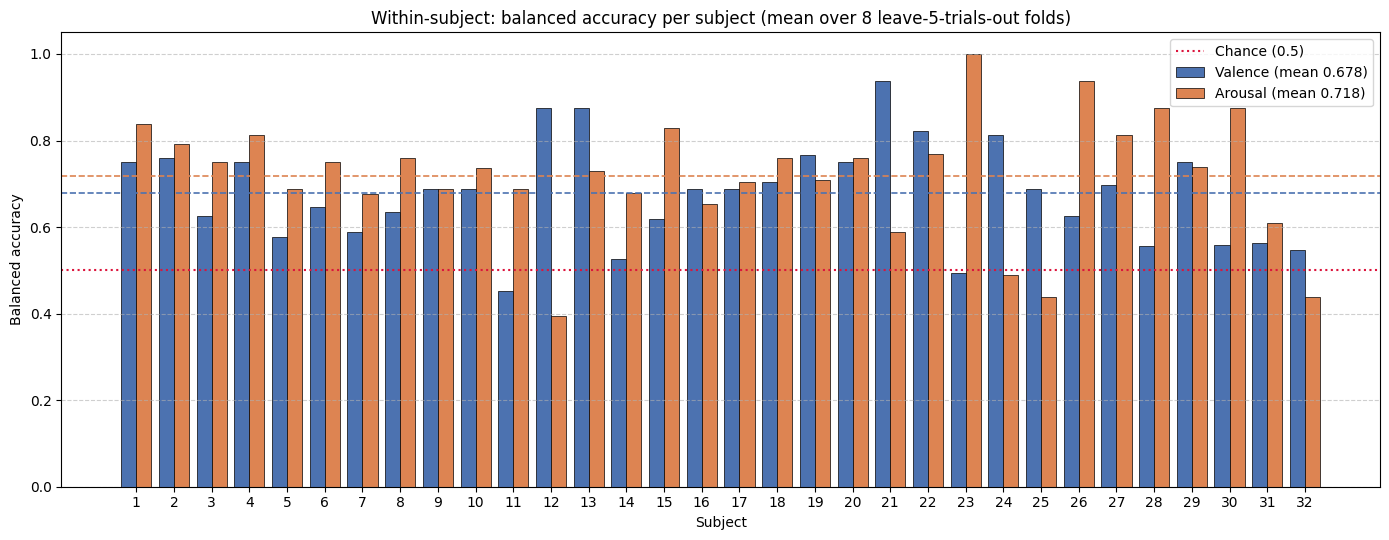

In [17]:
plot_per_subject("within_subject",
                 "Within-subject: balanced accuracy per subject (mean over 8 leave-5-trials-out folds)",
                 "emotionet_within_subject_balanced_accuracy.png")

Each bar is one subject's balanced accuracy averaged over their 8 folds; the dashed lines mark the across-subject mean for each target and the dotted red line marks chance (0.5). Although the mean accuracy across subjects is relatively high, and comparable with the accuracy reported in the original paper for both target labels, there is a lot of intersubject variability. This is to be expected, since different people have different profiles of emotion-related brain activity.

Research from motor imagery decoding suggests some people (15-30%) are so-called "BCI illiterate", meaning they cannot produce brain signals distinct enough to control a brain-computer interface (Vidaurre & Blankertz, 2010). It is possible this effect extends to passive BCI settings such as emotion recognition, but this assumption would need to be investigated further. Primarily, it would be necessary to first eliminate other potential explanations related to processing and classification, such as varying success at artifact removal, before blaming underlying biology for poor results.

### References

- S. Koelstra et al., "DEAP: A Database for Emotion Analysis Using Physiological Signals," *IEEE Transactions on Affective Computing*, 3(1), 2012.
- Y. Wang, Z. Huang, B. McCane and P. Neo, "EmotioNet: A 3-D Convolutional Neural Network for EEG-based Emotion Recognition," *International Joint Conference on Neural Networks (IJCNN)*, 2018.